In [1]:
import uproot
import dask_awkward as dak
import awkward as ak
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep
from dask.diagnostics import ProgressBar

In [2]:
plt.style.use(hep.style.CMS)

In [3]:
tree_path = "Events"
data_files = {f: tree_path for f in [
    "/eos/user/t/tdeandra/skim_outputs/Merged_Eras/Merged_dados_Run2022C.root",
    "/eos/user/t/tdeandra/skim_outputs/Merged_Eras/Merged_dados_Run2022D.root",
    "/eos/user/t/tdeandra/skim_outputs/Merged_Eras/Merged_dados_Run2022E.root",
    "/eos/user/t/tdeandra/skim_outputs/Merged_Eras/Merged_dados_Run2022F.root",
    "/eos/user/t/tdeandra/skim_outputs/Merged_Eras/Merged_dados_Run2022G.root"
]}

mc_files = {f: tree_path for f in [
    "/eos/user/t/tdeandra/skim_outputs/Merged_Eras/Merged_mc_signal_2022.root",
    "/eos/user/t/tdeandra/skim_outputs/Merged_Eras/Merged_mc_signal_2022EE.root"
]}

In [4]:
def get_b0_truth_mask(df):
    # --- 1. Constantes PDG ---
    PDG_B0        = 511
    PDG_KSTAR     = 313
    PDG_KAON_plus = 321
    PDG_PION_neg  = -211
    PDG_MUON_plus = -13
    PDG_MUON_neg  = 13
    PDG_PHOTON    = 22

    mu1_idx  = df["BPH_1Muon_genPartIdx"]
    mu2_idx  = df["BPH_2Muon_genPartIdx"]
    trk1_idx = df["Trk1_genPartIdx"]
    trk2_idx = df["Trk2_genPartIdx"]

    # Verificação de Identidade (PDG ID)
    mu1_pdg  = df["BPHGenPart_pdgId"][dak.mask(mu1_idx, mu1_idx >= 0)]
    mu2_pdg  = df["BPHGenPart_pdgId"][dak.mask(mu2_idx, mu2_idx >= 0)]
    trk1_pdg = df["BPHGenPart_pdgId"][dak.mask(trk1_idx, trk1_idx >= 0)]
    trk2_pdg = df["BPHGenPart_pdgId"][dak.mask(trk2_idx, trk2_idx >= 0)]

    flavor_match = (trk1_pdg == PDG_KAON_plus) & (trk2_pdg == PDG_PION_neg) & \
                   (mu1_pdg == PDG_MUON_plus) & (mu2_pdg == PDG_MUON_neg)

    # Linhagem do Hadron (K, Pi -> K* -> B0)
    mom_trk1_idx = df["BPHGenPart_genPartIdxMother"][dak.mask(trk1_idx, trk1_idx >= 0)]
    mom_trk2_idx = df["BPHGenPart_genPartIdxMother"][dak.mask(trk2_idx, trk2_idx >= 0)]
    
    mom_trk1_pdg = df["BPHGenPart_pdgId"][dak.mask(mom_trk1_idx, mom_trk1_idx >= 0)]
    mom_trk2_pdg = df["BPHGenPart_pdgId"][dak.mask(mom_trk2_idx, mom_trk2_idx >= 0)]
    
    # K e Pi devem vir do mesmo objeto K*0 
    match_kstar = (mom_trk1_idx == mom_trk2_idx) & (mom_trk1_idx >= 0) & \
                  (mom_trk1_pdg == PDG_KSTAR) & (mom_trk2_pdg == PDG_KSTAR)
    
    # O K*0 deve vir de um B0 (Verificando para ambos os traços)
    gmom_trk1_idx = df["BPHGenPart_genPartIdxMother"][dak.mask(mom_trk1_idx, mom_trk1_idx >= 0)]
    gmom_trk2_idx = df["BPHGenPart_genPartIdxMother"][dak.mask(mom_trk2_idx, mom_trk2_idx >= 0)]
    
    gmom_trk1_pdg = df["BPHGenPart_pdgId"][dak.mask(gmom_trk1_idx, gmom_trk1_idx >= 0)]
    gmom_trk2_pdg = df["BPHGenPart_pdgId"][dak.mask(gmom_trk2_idx, gmom_trk2_idx >= 0)]
    
    match_kstar_to_b0 = (gmom_trk1_idx == gmom_trk2_idx) & (gmom_trk1_idx >= 0) & \
                        (gmom_trk1_pdg == PDG_B0) & (gmom_trk2_pdg == PDG_B0)

    mom_mu1_idx = df["BPHGenPart_genPartIdxMother"][dak.mask(mu1_idx, mu1_idx >= 0)]
    mom_mu2_idx = df["BPHGenPart_genPartIdxMother"][dak.mask(mu2_idx, mu2_idx >= 0)]
    mom_mu1_pdg = df["BPHGenPart_pdgId"][dak.mask(mom_mu1_idx, mom_mu1_idx >= 0)]
    mom_mu2_pdg = df["BPHGenPart_pdgId"][dak.mask(mom_mu2_idx, mom_mu2_idx >= 0)]
    
    gmom_mu1_idx = df["BPHGenPart_genPartIdxMother"][dak.mask(mom_mu1_idx, mom_mu1_idx >= 0)]
    gmom_mu2_idx = df["BPHGenPart_genPartIdxMother"][dak.mask(mom_mu2_idx, mom_mu2_idx >= 0)]

    # Muon 1: Mãe é o B0 do hadron OU (Mãe é fóton e Avô é o B0 do hadron)
    mu1_from_same_b0 = (mom_mu1_idx == gmom_trk1_idx) | \
                       ((mom_mu1_pdg == PDG_PHOTON) & (gmom_mu1_idx == gmom_trk1_idx))

    mu2_from_same_b0 = (mom_mu2_idx == gmom_trk1_idx) | \
                       ((mom_mu2_pdg == PDG_PHOTON) & (gmom_mu2_idx == gmom_trk1_idx))

    # --- Máscara Final ---
    full_mask = flavor_match & match_kstar & match_kstar_to_b0 & \
                mu1_from_same_b0 & mu2_from_same_b0
    
    return ak.fill_none(full_mask, False)

In [5]:
def add_derived_columns(df):
    df["BToTrkTrkMuMu_l_xy_sig"] = df['BToTrkTrkMuMu_l_xy'] / df['BToTrkTrkMuMu_l_xy_unc']
    df["BToTrkTrkMuMu_dca_sig"]  = df['BToTrkTrkMuMu_dca'] / df['BToTrkTrkMuMu_dcaErr']
    df["BToTrkTrkMuMu_trk1_dca_sig"] = df['BToTrkTrkMuMu_trk1_dca'] / df['BToTrkTrkMuMu_trk1_dcaErr']
    df["BToTrkTrkMuMu_trk2_dca_sig"] = df['BToTrkTrkMuMu_trk2_dca'] / df['BToTrkTrkMuMu_trk2_dcaErr']
    return df

In [6]:
def apply_selection(df, mode="mc"):

    kstar_pdg = 0.892
    mask_kpi_window = abs(df['BToTrkTrkMuMu_fit_ditrack_mass_Kpi'] - kstar_pdg) <= 0.150
    mask_pik_window = abs(df['BToTrkTrkMuMu_fit_ditrack_mass_piK'] - kstar_pdg) <= 0.150
    is_kpi_closer = abs(df['BToTrkTrkMuMu_fit_ditrack_mass_Kpi'] - kstar_pdg) < \
                    abs(df['BToTrkTrkMuMu_fit_ditrack_mass_piK'] - kstar_pdg)
    
    mask = (
        # Filtro de massa de dimuons (regiões de sinal, excluindo J/psi e Psi2S)
        (((df['MuMu_mass'] > 1.0) & (df['MuMu_mass'] < 2.7)) | 
         ((df['MuMu_mass'] > 4.0) & (df['MuMu_mass'] < 6.0))) & 
        
        # Pelo menos uma das combinações deve estar na janela de 3 sigma
        (mask_kpi_window | mask_pik_window) & 
        
        # Aplicamos a lógica de decisão de sabor (escolhemos a hipótese Kpi se ela for a melhor)
        (is_kpi_closer) &
        
        # Trigger e cortes cinemáticos dos múons
        (df['HLT_DoubleMu4_3_LowMass'] == 1) & 
        (df['BPH_1Muon_pt'] > 2.0) & (df['BPH_2Muon_pt'] > 2.0) & 
        (abs(df['BPH_1Muon_eta']) < 2.4) & (abs(df['BPH_2Muon_eta']) < 2.4) &
        (df['BToTrkTrkMuMu_fit_trk1_pt'] > 1.5) &
        (df['BToTrkTrkMuMu_fit_trk2_pt'] > 1.5) 
    )
    if mode == "mc":
        mask = mask & (df['BToTrkTrkMuMu_fit_mass_Kpi'] >= 5.1251) & (df['BToTrkTrkMuMu_fit_mass_Kpi'] <= 5.4351)
        mask = mask & get_b0_truth_mask(df) # No MC junta a mask de thruth Matching !!!
        cols_to_keep = [
        'BToTrkTrkMuMu_l_xy_sig', 'BToTrkTrkMuMu_dca_sig', 
        'BToTrkTrkMuMu_trk1_dca_sig', 'BToTrkTrkMuMu_trk2_dca_sig', 
        'BToTrkTrkMuMu_fit_ditrack_mass_Kpi', 'BToTrkTrkMuMu_fit_pt', 
        'BToTrkTrkMuMu_fit_cos2D', 'BToTrkTrkMuMu_svprob', 'Pileup_nTrueInt'
        ]
    else:
        mask = mask & (
            ((df['BToTrkTrkMuMu_fit_mass_Kpi'] > 5.0) & (df['BToTrkTrkMuMu_fit_mass_Kpi'] < 5.1251)) | 
            ((df['BToTrkTrkMuMu_fit_mass_Kpi'] > 5.4351) & (df['BToTrkTrkMuMu_fit_mass_Kpi'] < 5.6))
        )
        cols_to_keep = [
        'BToTrkTrkMuMu_l_xy_sig', 'BToTrkTrkMuMu_dca_sig', 
        'BToTrkTrkMuMu_trk1_dca_sig', 'BToTrkTrkMuMu_trk2_dca_sig', 
        'BToTrkTrkMuMu_fit_ditrack_mass_Kpi', 'BToTrkTrkMuMu_fit_pt', 
        'BToTrkTrkMuMu_fit_cos2D', 'BToTrkTrkMuMu_svprob'
        ]

    return df[cols_to_keep][mask]

In [7]:
def build_dataframe(file_dict, label="Dataset", mode="mc"):
    print(f"\nProcessando {label}...")
    
    df = uproot.dask(file_dict)
    df = add_derived_columns(df)
    df = apply_selection(df, mode=mode)
    
    with ProgressBar():
        awkward_array = df.compute()
        df_pandas = ak.to_dataframe(awkward_array).reset_index(drop=True)
    
    print(f"{label} finalizado. Linhas: {len(df_pandas)}")
    return df_pandas

In [8]:
df_data = build_dataframe(data_files, "Data (Sidebands)", mode="data")
df_mc   = build_dataframe(mc_files, "MC Signal (Truth Matched)", mode="mc")


Processando Data (Sidebands)...
[########################################] | 100% Completed | 207.52 ms
[                                        ] | 0% Completed | 17.25 sms

/cvmfs/sft.cern.ch/lcg/views/LCG_109_cuda/x86_64-el9-gcc13-opt/lib/python3.13/site-packages/awkward/_nplikes/array_module.py:285: RuntimeWarning: divide by zero encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


[########################################] | 100% Completed | 69.47 s
Data (Sidebands) finalizado. Linhas: 88917

Processando MC Signal (Truth Matched)...
[########################################] | 100% Completed | 309.11 ms
[                                        ] | 0% Completed | 12.43 sms

/cvmfs/sft.cern.ch/lcg/views/LCG_109_cuda/x86_64-el9-gcc13-opt/lib/python3.13/site-packages/awkward/_nplikes/array_module.py:285: RuntimeWarning: divide by zero encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


[########################################] | 100% Completed | 19.26 s
MC Signal (Truth Matched) finalizado. Linhas: 185163


In [9]:
df_data["label"] = 0
df_mc["label"] = 1

In [10]:
pu_weight_arr = np.load("/eos/user/t/tdeandra/SWAN_projects/BPH_Analysis/MC_Analysis/Pileup_Correction/mc_weight.npy")

bins       = np.floor(df_mc['Pileup_nTrueInt'] + 0.5).astype(int)
valid_mask = (bins >= 0) & (bins < len(pu_weight_arr))

df_mc['pu_weight'] = 1.0
df_mc.loc[valid_mask, 'pu_weight'] = pu_weight_arr[bins[valid_mask]]
df_mc = df_mc.drop(columns=['Pileup_nTrueInt'])

In [11]:
df_mc['total_weight']   = df_mc['pu_weight'] # x outros SFs (ID, HLT, etc.) quando disponiveis
df_data['total_weight'] = 1.0                 # Aqui não há correção 

In [12]:
df_total = pd.concat([df_data, df_mc], ignore_index=True).sample(frac=1, random_state=42)
df_total = df_total.sample(frac=1, random_state=42).reset_index(drop=True)

In [13]:
features_plot = [
    'BToTrkTrkMuMu_l_xy_sig', 'BToTrkTrkMuMu_dca_sig', 
    'BToTrkTrkMuMu_trk1_dca_sig', 'BToTrkTrkMuMu_trk2_dca_sig',
    'BToTrkTrkMuMu_fit_ditrack_mass_Kpi', 'BToTrkTrkMuMu_fit_pt',
    'BToTrkTrkMuMu_fit_cos2D', 'BToTrkTrkMuMu_svprob'
]

labels_dict = {
    'BToTrkTrkMuMu_l_xy_sig': '$L_{BS}$ Sig.',
    'BToTrkTrkMuMu_dca_sig': '$B^{0}$ DCA Sig.',
    'BToTrkTrkMuMu_trk1_dca_sig': r'$Trk^{+}$ DCA Sig.',
    'BToTrkTrkMuMu_trk2_dca_sig': r'$Trk^{-}$ DCA Sig.',
    'BToTrkTrkMuMu_fit_ditrack_mass_Kpi': '$m(K\pi)$',
    'BToTrkTrkMuMu_fit_pt': '$p_T(B^{0})$',
    'BToTrkTrkMuMu_fit_cos2D': r'$\cos(\alpha_{2D})$',
    'BToTrkTrkMuMu_svprob': 'SV Prob.'
}

pretty_labels = [labels_dict.get(f, f) for f in features_plot]

<>:13: SyntaxWarning: invalid escape sequence '\p'
<>:13: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_1283/2773953258.py:13: SyntaxWarning: invalid escape sequence '\p'
  'BToTrkTrkMuMu_fit_ditrack_mass_Kpi': '$m(K\pi)$',


FileNotFoundError: [Errno 2] No such file or directory: 'PlotsEE/correlation_matrices.png'

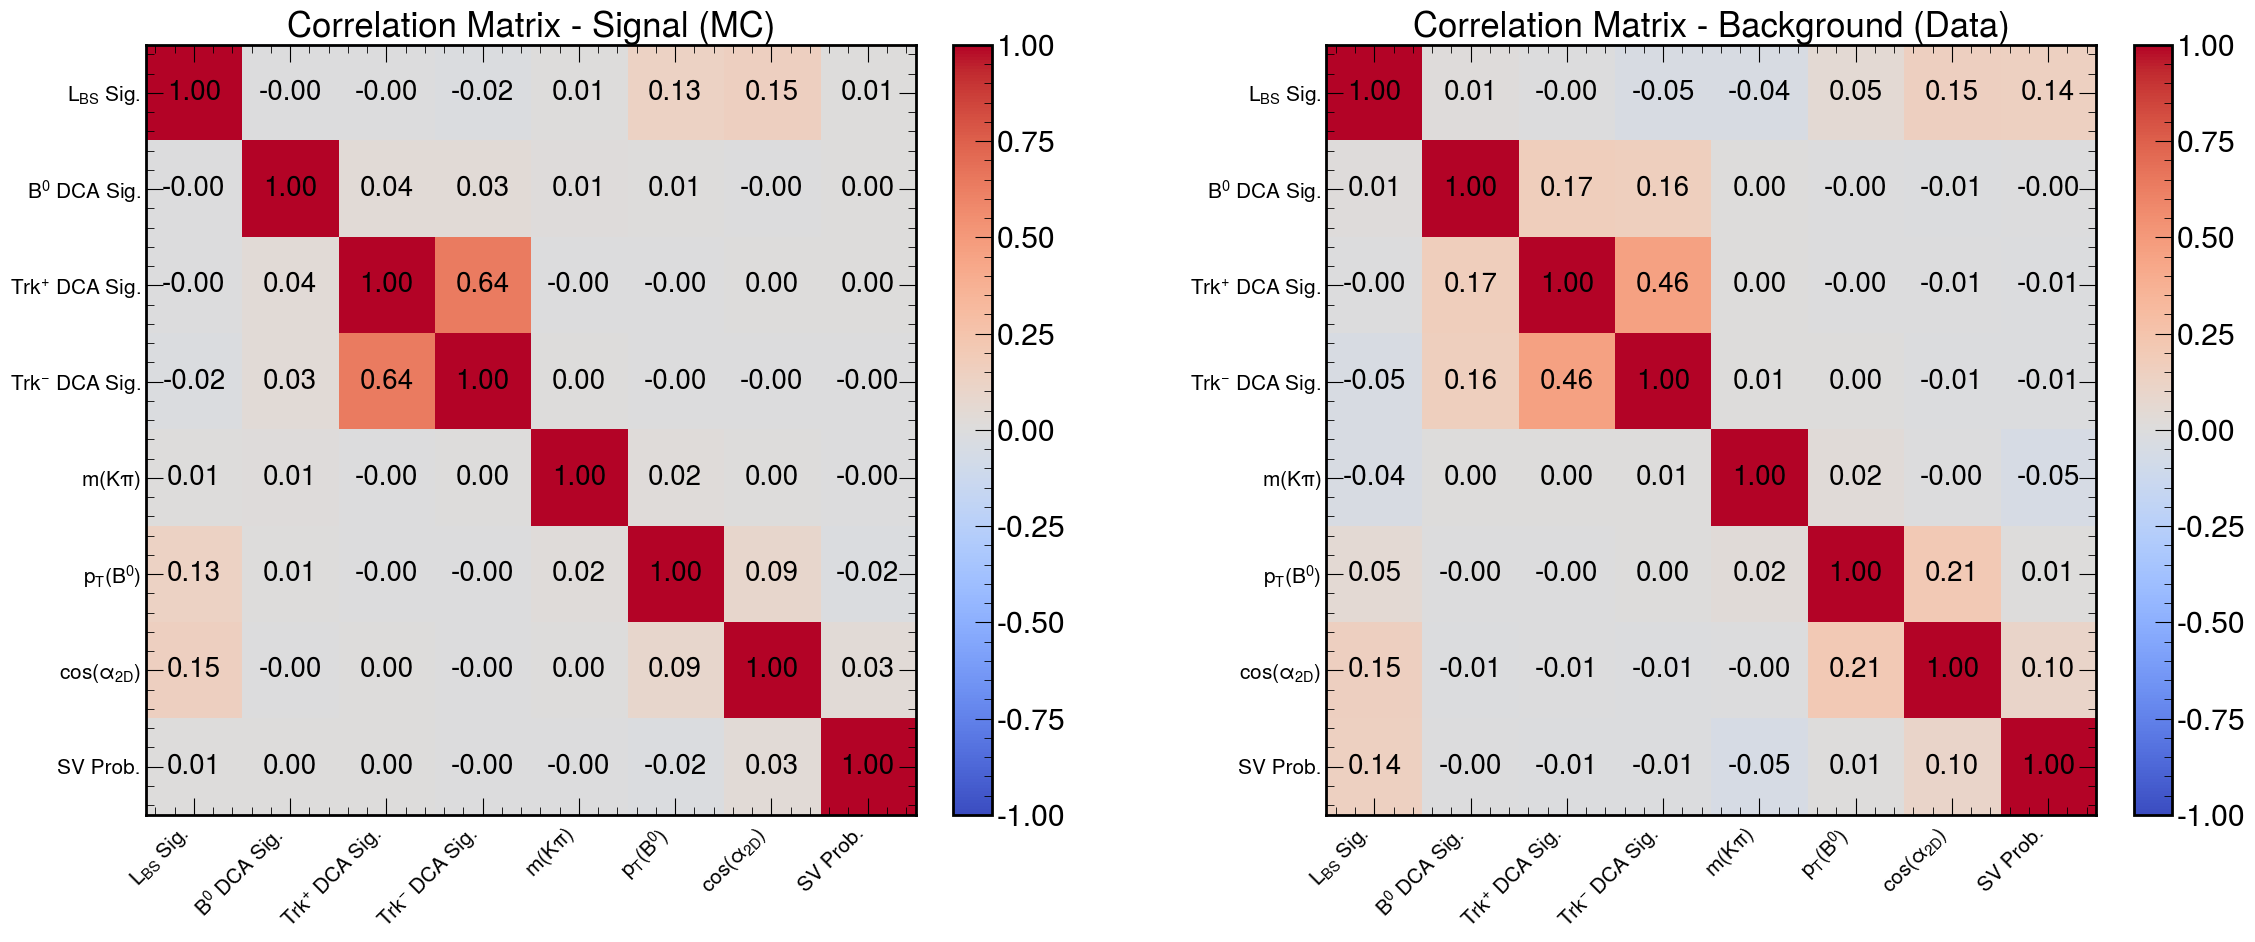

In [14]:
plt.figure(figsize=(24, 10))

# Subplot 1: Signal
ax1 = plt.subplot(1, 2, 1)
corr_signal = df_mc[features_plot].corr()
im1 = ax1.imshow(corr_signal, vmin=-1, vmax=1, cmap="coolwarm")
plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
ax1.set_title("Correlation Matrix - Signal (MC)", fontsize=25)
ax1.set_xticks(np.arange(len(features_plot)))
ax1.set_yticks(np.arange(len(features_plot)))
ax1.set_xticklabels(pretty_labels, rotation=45, ha="right", fontsize=15)
ax1.set_yticklabels(pretty_labels, fontsize=15)

for i in range(len(features_plot)):
    for j in range(len(features_plot)):
        ax1.text(j, i, f"{corr_signal.iloc[i, j]:.2f}", ha="center", va="center", color="black", fontsize=20)

# Subplot 2: Background
ax2 = plt.subplot(1, 2, 2)
corr_background = df_data[features_plot].corr()
im2 = ax2.imshow(corr_background, vmin=-1, vmax=1, cmap="coolwarm")
plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
ax2.set_title("Correlation Matrix - Background (Data)", fontsize=25)
ax2.set_xticks(np.arange(len(features_plot)))
ax2.set_yticks(np.arange(len(features_plot)))
ax2.set_xticklabels(pretty_labels, rotation=45, ha="right", fontsize=15)
ax2.set_yticklabels(pretty_labels, fontsize=15)

for i in range(len(features_plot)):
    for j in range(len(features_plot)):
        ax2.text(j, i, f"{corr_background.iloc[i, j]:.2f}", ha="center", va="center", color="black", fontsize=20)

plt.tight_layout()
plt.savefig("PlotsEE/correlation_matrices.png", dpi=300)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'PlotsEE/Overlay_Weighted.png'

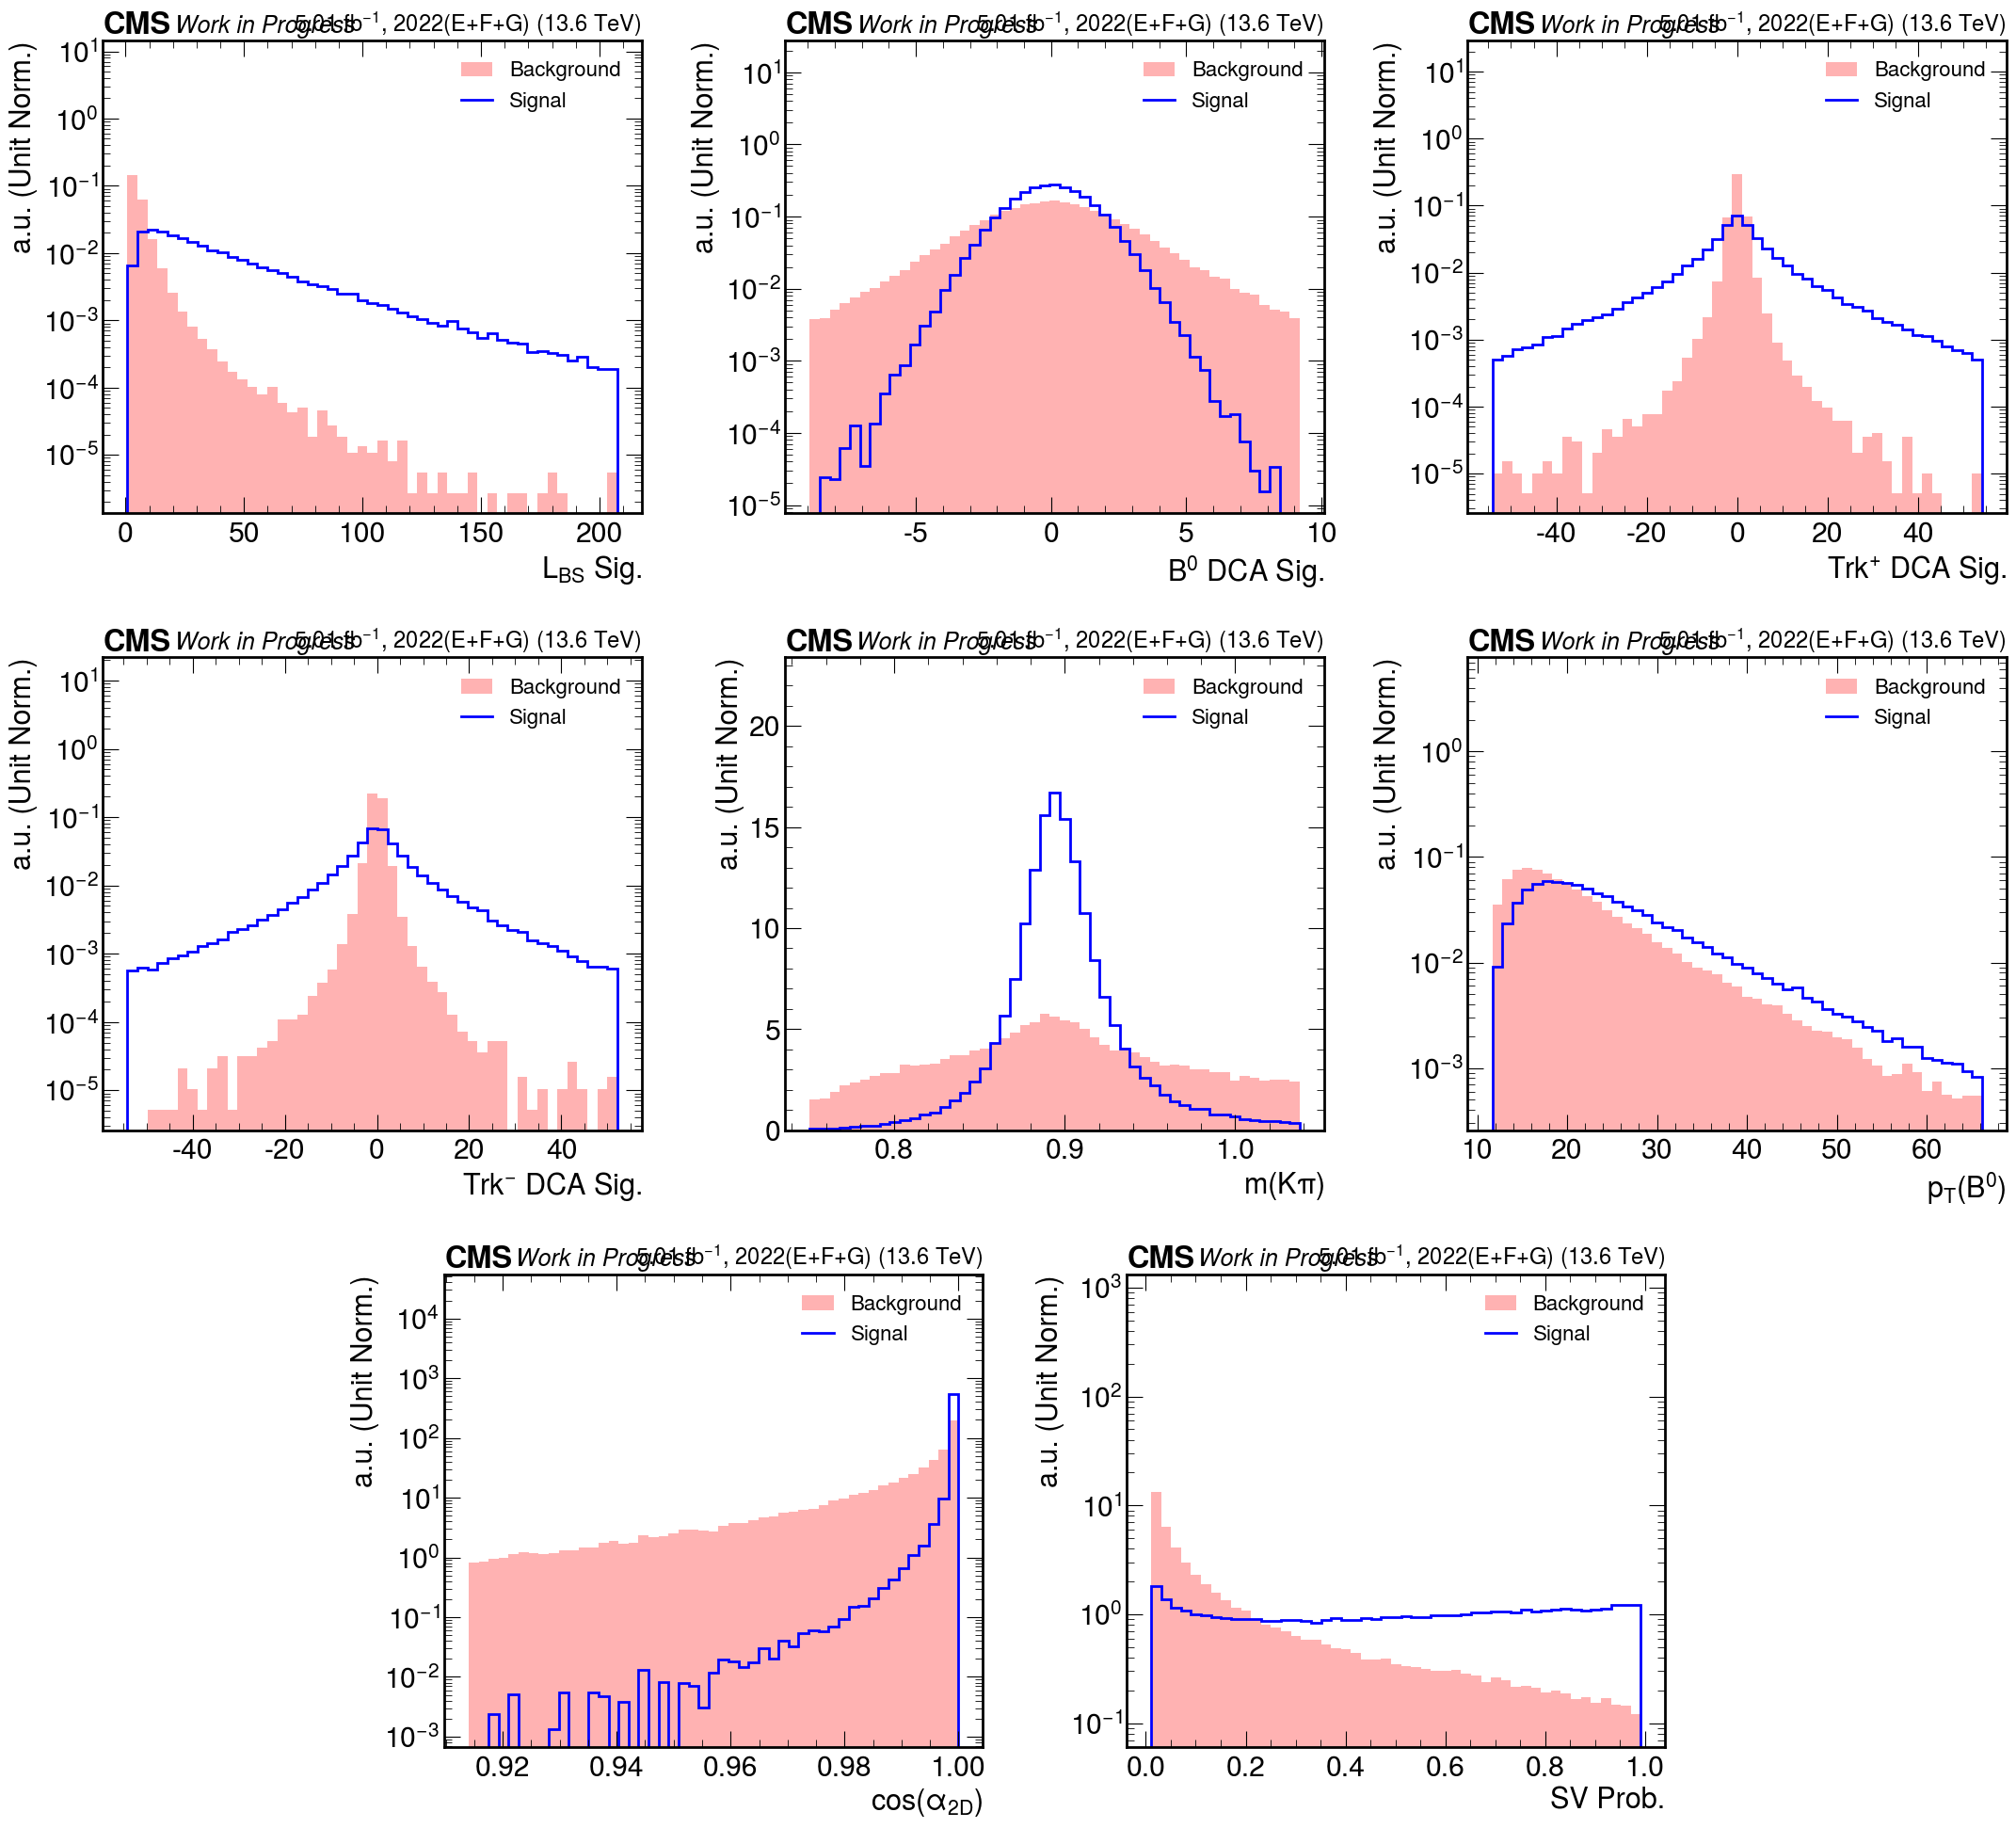

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep
import pandas as pd

# Definindo o estilo do CMS
plt.style.use(hep.style.CMS)

def plot_custom_grid(df, features, log_features=[], labels_map={}):
    """
    Plota um grid de histogramas comparando Sinal e Fundo, 
    levando em conta os pesos de física (total_weight).
    """
    fig = plt.figure(figsize=(22, 20))
    gs = fig.add_gridspec(3, 6)
    
    axes = []
    # Definindo a posição dos subplots no grid
    axes.append(fig.add_subplot(gs[0, 0:2])) 
    axes.append(fig.add_subplot(gs[0, 2:4])) 
    axes.append(fig.add_subplot(gs[0, 4:6])) 
    axes.append(fig.add_subplot(gs[1, 0:2]))
    axes.append(fig.add_subplot(gs[1, 2:4]))
    axes.append(fig.add_subplot(gs[1, 4:6]))
    axes.append(fig.add_subplot(gs[2, 1:3])) 
    axes.append(fig.add_subplot(gs[2, 3:5])) 
    
    for i, feature in enumerate(features):
        if i >= len(axes): break
        
        ax = axes[i]
        
        # 1. Filtro de Máscara para Sinal (1) e Background (0)
        mask_sig = df['label'] == 1
        mask_bkg = df['label'] == 0
        
        # 2. Extração de dados e pesos garantindo que não haja NaNs
        # O .loc[...index] garante que o array de pesos tenha o mesmo tamanho que o de dados
        sig_data = df[mask_sig][feature].dropna()
        sig_weights = df[mask_sig]['total_weight'].loc[sig_data.index]
        
        bkg_data = df[mask_bkg][feature].dropna()
        bkg_weights = df[mask_bkg]['total_weight'].loc[bkg_data.index]
        
        if len(sig_data) == 0 or len(bkg_data) == 0:
            print(f"Aviso: {feature} sem dados suficientes para plotar.")
            continue

        # 3. Definição dos Bins (baseado em percentis para evitar outliers estragarem o plot)
        low = min(np.percentile(sig_data, 1), np.percentile(bkg_data, 1))
        high = max(np.percentile(sig_data, 99), np.percentile(bkg_data, 99))
        bins = np.linspace(low, high, 50)
        
        # 4. Cálculo dos Histogramas Ponderados
        # density=True é essencial para comparar as FORMAS (shapes) como pede a AN
        counts_bkg, _ = np.histogram(bkg_data, bins=bins, weights=bkg_weights, density=True)
        counts_sig, _ = np.histogram(sig_data, bins=bins, weights=sig_weights, density=True)
        
        # 5. Plotagem com mplhep
        hep.histplot(counts_bkg, bins=bins, ax=ax, label='Background', 
                     color='red', alpha=0.3, histtype='fill')        
        hep.histplot(counts_sig, bins=bins, ax=ax, label='Signal', 
                     color='blue', linewidth=2, histtype='step')
        
        # 6. Configuração de Escala Logarítmica
        if feature in log_features:
            ax.set_yscale('log')
            all_counts = np.concatenate([counts_bkg, counts_sig])
            valid_counts = all_counts[all_counts > 0]
            if len(valid_counts) > 0:
                min_val = np.min(valid_counts)
                ax.set_ylim(bottom=min_val * 0.5, top=np.max(all_counts) * 100)
        else:
            ax.set_ylim(top=np.max(np.concatenate([counts_bkg, counts_sig])) * 1.4)

        # 7. Estética e Labels
        pretty_name = labels_map.get(feature, feature)        
        ax.set_xlabel(pretty_name, fontsize=22)
        ax.set_ylabel("a.u. (Unit Norm.)", fontsize=22)
        ax.legend(loc='upper right', fontsize=16)
        
        # Selo do CMS
        hep.cms.label(
            ax=ax,
            label="Work in Progress",
            data=True,
            lumi=5.01,
            year="2022(E+F+G)",
            com=13.6,
            fontsize=18
        )

    plt.tight_layout()
    plt.savefig("PlotsEE/Overlay_Weighted.png", dpi=300)
    plt.show()

# --- Execução ---

features_para_log = [
    "BToTrkTrkMuMu_l_xy_sig",
    "BToTrkTrkMuMu_dca_sig",
    "BToTrkTrkMuMu_trk1_dca_sig",
    "BToTrkTrkMuMu_trk2_dca_sig",
    "BToTrkTrkMuMu_fit_pt",
    "BToTrkTrkMuMu_fit_cos2D",
    "BToTrkTrkMuMu_svprob"
]

# Certifique-se que df_total tenha as colunas 'label', 'total_weight' e as features
plot_custom_grid(
    df_total, 
    features_plot, 
    log_features=features_para_log, 
    labels_map=labels_dict
)